# Ridge Regression - Introduction


La funzione $J(w)$ è definita come la somma dell'errore quadratico sui dati (Residual Sum of Squares) e un termine di penalità (la norma L2 dei pesi, moltiplicata per $\lambda$).

---

## 1. Versione Algebrica (Sommatoria)

Questa forma mostra la somma degli errori al quadrato per ogni punto dati ($i=1$ a $n$) più la somma dei quadrati dei pesi (da $j=1$ a $d$).

Assumiamo che la matrice $X$ includa già la colonna di $1$ per il termine di intercetta ($w_0$) e che quindi il vettore dei pesi $w$ abbia dimensione $d$.

$$J(w) = \frac{1}{2n} \sum_{i=1}^{n} (y_i - x_i^T w)^2 + \frac{\lambda}{2} \sum_{j=1}^{d} w_j^2$$

Dove:
* $n$: Numero totale di campioni (righe).
* $x_i$: La $i$-esima riga della matrice $X$ (un singolo campione).
* $y_i$: Il valore target per il campione $i$.
* $w_j$: Il $j$-esimo peso nel vettore $w$.
* $x_i^T w$: La predizione lineare per il campione $i$.
* **$\frac{1}{2n}$**: Fattore di scala opzionale (ma consigliato) che mantiene l'obiettivo e il gradiente indipendenti dal numero di campioni, e il $\frac{1}{2}$ semplifica la derivazione successiva.

---

## 2. Versione Matriciale (Vettoriale)

Questa forma è quella che utilizzerai direttamente nel codice Python, in quanto è ottimizzata per l'algebra lineare di NumPy.

$$J(w) = \frac{1}{2n} \|y - Xw\|_2^2 + \frac{\lambda}{2} \|w\|_2^2$$

Dove:
* $\|Xw - y\|_2^2$: Rappresenta l'errore quadratico totale: è la norma euclidea (o norma L2) del vettore dei residui ($Xw - y$).
    * *Espansione (per il codice):* $(Xw - y)^T (Xw - y)$.
* $\|w\|_2^2$: Rappresenta la penalità L2, ovvero la norma euclidea del vettore dei pesi.
    * *Espansione (per il codice):* $w^T w$.

Questa formula matriciale è la base per derivare il gradiente (di cui avrai bisogno per il Gradient Descent) e l'Hessiana (necessaria per il Metodo di Newton).

---

## 3. Derivazione del Gradiente

Per tua completezza, il gradiente $\nabla J(w)$ (necessario per tutti gli algoritmi basati sul gradiente) è dato da:

$$\nabla J(w) = \frac{1}{n} X^T (Xw - y) + \lambda w$$

Sei pronto per implementare la classe **Gradient Descent** (con e senza Nesterov) basata su questa formula del gradiente?


Abbiamo aggiunto il termine $\frac{1}{2n}$ per due ragioni fondamentali legate all'**ottimizzazione numerica** e alla **stabilità del codice**, che sono cruciali per il tuo progetto di confronto tra algoritmi.

***

## 1. Il Termine $\frac{1}{n}$: Normalizzazione del Costo (Scaling)

Il fattore $\frac{1}{n}$ (dove $n$ è il numero di campioni, circa 45.000 nel tuo caso) converte la **somma degli errori quadratici** in **errore quadratico medio (Mean Squared Error - MSE)**.

* **Stabilità del Gradiente:** Nel tuo progetto confronterai il **Gradiente Discesa** con lo **Stochastic Gradient Descent (SGD)**. Il gradiente di GD usa tutti gli $n$ campioni, mentre il gradiente di SGD ne usa solo $B$ (il batch size). Se non normalizzi, il gradiente di GD sarà $n$ volte più grande di quello di SGD (o $n/B$ volte più grande del Mini-batch SGD). Dividendo per $n$, la magnitudine del tuo gradiente diventa **indipendente dalla dimensione del dataset**, rendendo il *learning rate* $\eta$ (e la costante $L$) più stabili e universali tra i diversi algoritmi.
* **Confronto:** Il valore di Loss che ottieni è un costo medio, non un costo totale. Questo ti permette di confrontare la Loss di questo dataset da 45k righe con la Loss di qualsiasi altro dataset in futuro.

***

## 2. Il Termine $\frac{1}{2}$: Semplificazione Analitica

Il fattore $\frac{1}{2}$ è una convenzione matematica usata per **semplificare la derivazione del gradiente**.

Ricordi la regola della catena per la derivata di una funzione quadratica: $\frac{d}{dx} x^2 = 2x$.

Quando calcolerai il gradiente $\nabla J(w)$, l'esponente $2$ della norma quadratica $\frac{1}{2n} \|Xw - y\|_2^2$ si abbasserà e **cancellerà esattamente il $\frac{1}{2}$ a denominatore**.

$$\nabla \left( \frac{1}{2n} \|Xw - y\|_2^2 \right) \quad \longrightarrow \quad \frac{1}{n} X^T (Xw - y)$$

Questo rende la formula del gradiente molto più pulita e facile da implementare.

---

### Conclusione: La Posizione del Minimo $w^*$ non cambia

È importante notare che, poiché $\frac{1}{2n}$ è una **costante positiva**, moltiplicare l'intera funzione obiettivo per $\frac{1}{2n}$ non sposta la posizione del minimo $w^*$.

$$\arg\min_w \left[ \|Xw - y\|_2^2 + \lambda \|w\|_2^2 \right] = \arg\min_w \left[ \frac{1}{2n} \|Xw - y\|_2^2 + \frac{\lambda}{2n} \|w\|_2^2 \right]$$

L'unica cosa che cambia è che, se usi il termine $\frac{1}{2n}$, devi ricordarti di **ridimensionare $\lambda$** (il tuo iperparametro) nello stesso modo, ma poiché $\lambda$ è un valore che scegli tu, basta sceglierlo in un range appropriato.

È stato scelto di usare la versione $\frac{1}{2n}$ perché è la prassi moderna per gli studi di ottimizzazione che includono l'SGD.

Ecco le derivazioni e le formule finali per il **Gradiente** e la **Hessiana** della Ridge Regression, basate sulla funzione obiettivo che abbiamo definito:

$$f(w) = \frac{1}{2n} \|y - Xw\|_2^2 + \frac{\lambda}{2} \|w\|_2^2$$

-----

### 1\. Il Gradiente $\nabla f(w)$

Il gradiente è un vettore di dimensione $d$ (numero di feature) che indica la direzione di massima pendenza. È composto dalla somma di due derivate: quella dell'errore (Data fidelity) e quella della regolarizzazione.

**Formula Matematica:**
$$\nabla f(w) = \frac{1}{n} X^T (Xw - y) + \lambda w$$

**Spiegazione dei termini:**

  * $\frac{1}{n} X^T (Xw - y)$: È il gradiente medio dell'errore quadratico. Spinge $w$ verso la soluzione che minimizza l'errore sui dati.
  * $\lambda w$: È il gradiente della regolarizzazione (derivata di $\frac{\lambda}{2}w^2$). Spinge $w$ verso lo zero (shrinkage).

-----

### 2\. La Hessiana $\nabla^2 f(w)$

La Hessiana è una matrice quadrata $d \times d$ che rappresenta la curvatura della funzione (derivata seconda).
Poiché la Ridge Regression è un problema **quadratico**, la curvatura è costante ovunque (è una parabola perfetta).

**Formula Matematica:**
$$\nabla^2 f(w) = \frac{1}{n} X^T X + \lambda I$$

**Spiegazione dei termini:**

  * $\frac{1}{n} X^T X$: È la matrice di covarianza delle feature (scalata). Definisce la forma della "valle".
  * $\lambda I$: È la matrice identità moltiplicata per lambda. Aggiunge $\lambda$ alla diagonale principale.
      * *Effetto "Ridge" (Cresta):* Anche se $X^T X$ fosse singolare (non invertibile), l'aggiunta di $\lambda I$ rende la Hessiana definita positiva e quindi invertibile. Questo è il motivo per cui la Ridge è robusta.

-----

### 💡 Un trucco per l'efficienza (Optimization Tip)

Nota una differenza fondamentale tra Gradiente e Hessiana:

1.  Il **Gradiente** dipende da $w$. Devi ricalcolarlo ad ogni iterazione ($k=1, 2, \dots$).
2.  La **Hessiana** *non* dipende da $w$. È costante.
      * **Per il Metodo di Newton:** Non ricalcolare l'Hessiana dentro il ciclo `for`\! Calcolala **una sola volta** prima di iniziare il ciclo, invertila (o fattorizzala), e usa quella matrice costante per tutti i passaggi. Questo renderà il tuo codice Newton incredibilmente veloce.

# Ridge Regression - Computing Gradient and Hessian Matrix

Certamente. Questa funzione $f(w)$ è la funzione di costo della **Ridge Regression** in forma matriciale.

Analizzeremo il problema in due parti: prima espandiamo l'algebra matriciale per semplificare la derivazione, poi calcoliamo il Gradiente (derivata prima) e infine la matrice Hessiana (derivata seconda).

### Preliminari e Convenzioni
Assumiamo le convenzioni standard (coerenti con la tua domanda precedente):
* $w \in \mathbb{R}^d$ (vettore colonna)
* $y \in \mathbb{R}^n$ (vettore colonna)
* $X \in \mathbb{R}^{n \times d}$ (matrice)
* La norma $L_2$ al quadrato di un vettore $v$ è definita come $\|v\|_2^2 = v^T v$.

---

### Passo 1: Espansione della funzione
Prima di derivare, è utile riscrivere la norma vettoriale come prodotto matriciale ed espandere i termini.

La funzione è:
$$f(w) = \underbrace{\frac{1}{2n} (y - Xw)^T (y - Xw)}_{\text{Errore Quadratico}} + \underbrace{\frac{\lambda}{2} w^T w}_{\text{Regolarizzazione}}$$

Espandiamo il termine dell'errore quadratico:
$$
\begin{aligned}
(y - Xw)^T (y - Xw) &= (y^T - (Xw)^T)(y - Xw) \\
&= (y^T - w^T X^T)(y - Xw) \\
&= y^T y - y^T X w - w^T X^T y + w^T X^T X w
\end{aligned}
$$

**Nota cruciale (lo scalare):**
I termini $y^T X w$ e $w^T X^T y$ sono scalari (risultato $1 \times 1$).
In algebra lineare, la trasposta di uno scalare è lo scalare stesso.
Notiamo che $(y^T X w)^T = w^T X^T y$.
Quindi questi due termini sono identici e possono essere sommati:
$$- y^T X w - w^T X^T y = -2 w^T X^T y$$

Sostituendo tutto nella funzione $f(w)$ originale ed espandendo:
$$
f(w) = \frac{1}{2n} \left( y^T y - 2 w^T X^T y + w^T X^T X w \right) + \frac{\lambda}{2} w^T w
$$

Ora siamo pronti per derivare.

---

### Passo 2: Calcolo del Gradiente $\nabla f(w)$

Il gradiente è il vettore delle derivate parziali rispetto a $w$. Usiamo le seguenti identità del calcolo matriciale (dove $A$ è una matrice simmetrica):
1.  $\nabla_w (b) = 0$ (costante)
2.  $\nabla_w (w^T b) = \nabla_w (b^T w) = b$
3.  $\nabla_w (w^T A w) = 2Aw$

Applichiamo queste regole a ogni termine di $f(w)$:

1.  **Termine $y^T y$**: Non dipende da $w$.
    $$\nabla_w (\dots) = 0$$

2.  **Termine $-2 w^T (X^T y)$**: Qui $b = X^T y$.
    $$\nabla_w \left( \frac{1}{2n} (-2 w^T X^T y) \right) = -\frac{1}{n} \nabla_w (w^T (X^T y)) = -\frac{1}{n} X^T y$$

3.  **Termine $w^T (X^T X) w$**: Qui $A = X^T X$. Notiamo che $X^T X$ è simmetrica.
    $$\nabla_w \left( \frac{1}{2n} w^T X^T X w \right) = \frac{1}{2n} (2 X^T X w) = \frac{1}{n} X^T X w$$

4.  **Termine regolarizzazione $\frac{\lambda}{2} w^T w$**: Qui $A = I$ (matrice identità).
    $$\nabla_w \left( \frac{\lambda}{2} w^T I w \right) = \frac{\lambda}{2} (2 I w) = \lambda w$$

**Risultato Gradiente:**
Sommiamo i pezzi:
$$
\nabla f(w) = \frac{1}{n} (X^T X w - X^T y) + \lambda w
$$
Raccogliendo i termini simili, spesso si scrive anche come:
$$\nabla f(w) = \frac{1}{n} X^T (Xw - y) + \lambda w$$

---

### Passo 3: Calcolo della Matrice Hessiana $\nabla^2 f(w)$

La matrice Hessiana è la derivata del gradiente rispetto a $w$ (ovvero la derivata seconda della funzione originale). È una matrice $d \times d$.

Riprendiamo l'espressione del gradiente:
$$\nabla f(w) = \frac{1}{n} X^T X w - \frac{1}{n} X^T y + \lambda w$$

Deriviamo ogni termine rispetto a $w$. Usiamo l'identità $\nabla_w (Aw) = A$:

1.  **Termine $\frac{1}{n} X^T X w$**:
    La matrice costante che moltiplica $w$ è $\frac{1}{n} X^T X$.
    $$\nabla^2 (\dots) = \frac{1}{n} X^T X$$

2.  **Termine $-\frac{1}{n} X^T y$**:
    Questo termine non contiene $w$ (è un vettore costante).
    $$\nabla^2 (\dots) = 0$$

3.  **Termine $\lambda w$**:
    Possiamo scriverlo come $\lambda I w$. La matrice costante è $\lambda I$.
    $$\nabla^2 (\dots) = \lambda I$$

**Risultato Hessiana:**
$$
H = \nabla^2 f(w) = \frac{1}{n} X^T X + \lambda I
$$

### Conclusioni sull'Hessiana
Questa formula è molto importante per capire le proprietà della Ridge Regression:
* La matrice $X^T X$ è semidefinita positiva (i suoi autovalori sono $\ge 0$).
* Oss: Una matrice simmetrica $A$ è semidefinita positiva (PSD) se, per qualsiasi vettore non nullo $v$, vale la condizione:$$v^T A v \geq 0$$
* Aggiungendo $\lambda I$ (con $\lambda > 0$), stiamo sommando $\lambda$ a tutti gli autovalori.
* Di conseguenza, l'Hessiana è **definita positiva** (tutti gli autovalori $> 0$).
* Questo garantisce che la funzione $f(w)$ è **strettamente convessa**, assicurando che esista una soluzione unica (il minimo globale) e rendendo l'ottimizzazione molto stabile.

È un passaggio matematico molto elegante e incredibilmente utile. Per capirlo a fondo, basta guardare la definizione algebrica di **autovettore** e **autovalore**.

Ecco la dimostrazione passo-passo del perché sommare la matrice identità equivale a sommare una costante agli autovalori.

### 1\. La definizione di partenza

Immagina una matrice quadrata $A$ (nel nostro caso $A = \frac{1}{n}X^T X$).
Se $v$ è un autovettore di $A$ e $\mu$ è il suo autovalore associato, vale per definizione l'equazione:

$$A v = \mu v$$

### 2\. Aggiungiamo $\lambda I$

Ora consideriamo la nuova matrice Hessiana regolarizzata: $H = A + \lambda I$.
Vogliamo vedere come questa nuova matrice agisce sullo **stesso** vettore $v$. Moltiplichiamo $H$ per $v$:

$$
H v = (A + \lambda I) v
$$

Distribuiamo la moltiplicazione:

$$
= A v + (\lambda I) v
$$

Poiché la matrice identità $I$ moltiplicata per qualsiasi vettore lo lascia invariato ($Iv = v$), otteniamo:

$$
= A v + \lambda v
$$

Ora usiamo la definizione iniziale ($Av = \mu v$) per sostituire il primo termine:

$$
= \mu v + \lambda v
$$

Raccogliamo il vettore comune $v$:

$$
H v = (\mu + \lambda) v
$$

### 3\. La conclusione logica

Confrontiamo l'inizio e la fine:
$$H v = (\underbrace{\mu + \lambda}_{\text{nuovo autovalore}}) v$$

Questo ci dice due cose fondamentali:

1.  **Gli autovettori non cambiano:** $v$ è ancora un autovettore della nuova matrice.
2.  **Gli autovalori sono traslati:** Se il vecchio autovalore era $\mu$, il nuovo è esattamente $\mu + \lambda$.

-----

### Perché questo rende la matrice "Definita Positiva"?

Colleghiamo questo risultato alle proprietà della matrice $X^T X$:

1.  **Situazione Originale (Senza Ridge):**
    Gli autovalori $\mu$ di $X^T X$ sono sempre $\ge 0$ (semidefiniti positivi).
    Tuttavia, se i dati sono collineari o se hai poche osservazioni, uno o più autovalori potrebbero essere **esattamente 0**.

      * Autovalore $0 \rightarrow$ Curvatura piatta $\rightarrow$ Determinante $0$ $\rightarrow$ **Matrice non invertibile**.

2.  **Situazione Regolarizzata (Con Ridge):**
    I nuovi autovalori sono $\mu_{new} = \mu + \lambda$.
    Dato che $\mu \ge 0$ e noi scegliamo $\lambda > 0$:

    $$
    $$

    $$
    $$

    \\mu\_{new} \\ge 0 + \\lambda \\implies \\mu\_{new} \> 0

    $$
    $$

    $$
    $$

    Tutti i nuovi autovalori sono **strettamente positivi**.

      * Autovalori tutti positivi $\rightarrow$ Curvatura "a scodella" in tutte le direzioni $\rightarrow$ Determinante $> 0$ $\rightarrow$ **Matrice sempre invertibile**.

In termini geometrici, laddove la funzione di costo originale potrebbe avere una "valle piatta" (infinite soluzioni possibili), l'aggiunta di $\lambda I$ piega quella valle facendola diventare una "conca", garantendo un unico punto di minimo stabile.


# Ridge Regression - Properties

Ecco un'analisi dettagliata delle proprietà della Ridge Regression. Queste definizioni sono il "cuore teorico" del tuo progetto e giustificano perché certi algoritmi funzionano meglio di altri.

### 1\. Le Proprietà Matematiche (La "Carta d'Identità")

La tua funzione obiettivo è:
$$f(w) = \frac{1}{2n} \|Xw - y\|_2^2 + \frac{\lambda}{2} \|w\|_2^2$$

Per capire le proprietà, guardiamo la **Hessiana** (la curvatura), che abbiamo calcolato essere costante:
$$H = \nabla^2 f(w) = \frac{1}{n} X^T X + \lambda I$$

Ecco le 4 proprietà chiave derivate da $H$:

#### **A. Convessità (Convexity)**

  * **Verdetto:** La funzione è **Strettamente Convessa** (Strictly Convex).
  * **Perché:** La matrice $X^T X$ è Semidefinita Positiva (autovalori $\ge 0$). Aggiungendo $\lambda I$ (con $\lambda > 0$), aggiungiamo un numero positivo a tutti gli autovalori. Quindi la Hessiana è **Definita Positiva** ovunque.
  * **Conseguenza:** Esiste **uno e un solo minimo globale** $w^*$. Non ci sono minimi locali o punti di sella dove gli algoritmi possono incastrarsi.

#### **B. Forte Convessità (Strong Convexity)**

  * **Verdetto:** È **$\mu$-Strongly Convex**.
  * **Definizione:** La curvatura è "almeno" $\mu$ in ogni direzione. La funzione sta sempre sopra una parabola stretta.
  * **Valore di $\mu$:** È il più piccolo autovalore della Hessiana.
    $$\mu = \lambda_{\min}\left(\frac{1}{n}X^T X\right) + \lambda$$
    *(Nota: Se $X$ non è full-rank, il primo termine è 0, quindi $\mu = \lambda$. Questo ci dice che senza regolarizzazione ($\lambda=0$), il problema potrebbe non essere fortemente convesso, rendendo la convergenza molto più lenta).*
  * **Conseguenza:** Garantisce la convergenza **Lineare** (veloce) del Gradiente Discesa. Più grande è $\mu$, più veloce è la convergenza.

#### **C. Smoothness (Lipschitz Continuous Gradient)**

  * **Verdetto:** È **$L$-Smooth**.
  * **Definizione:** La curvatura non cambia bruscamente; il gradiente non impazzisce. La funzione sta sempre "sotto" una certa parabola.
  * **Valore di $L$:** È il più grande autovalore della Hessiana (la massima curvatura).
    $$L = \lambda_{\max}\left(\frac{1}{n}X^T X\right) + \lambda$$
  * **Conseguenza:** Questo valore ti dà il **limite di velocità** per il Gradiente Discesa. Se usi un learning rate $\eta > \frac{2}{L}$, l'algoritmo divergerà (esploderà). Il passo sicuro ottimale è $1/L$.

#### **D. Differentiability**

  * **Verdetto:** La funzione è $C^\infty$ (infinitamente differenziabile).
  * **Perché:** È composta solo da somme e prodotti di polinomi (termini quadratici). Non ci sono valori assoluti (come nella Lasso Regression) o "spigoli".

-----

### 2\. Perché la Ridge è una "Palestra" perfetta per l'Ottimizzazione?

Perché scegliere proprio la Ridge Regression per confrontare gli algoritmi e non una rete neurale complessa? Ecco i motivi didattici e scientifici:

#### **1. Il "Laboratorio Controllato" (Condition Number)**

Il rapporto tra $L$ e $\mu$ si chiama **Numero di Condizionamento** ($\kappa = L/\mu$).

  * Se $\kappa \approx 1$: La funzione è una ciotola perfettamente rotonda. GD converge all'istante.
  * Se $\kappa \gg 1$: La funzione è una valle stretta e lunga (un "burrone"). GD fa zig-zag.

**La bellezza della Ridge:** Cambiando $\lambda$, **tu controlli la difficoltà del problema**.

  * $\lambda$ alto $\to$ $\mu$ alto $\to$ $\kappa$ basso $\to$ Problema Facile.
  * $\lambda$ basso $\to$ $\mu \approx 0$ $\to$ $\kappa$ enorme $\to$ Problema Difficile (Mal condizionato).
  * *Nel progetto:* Puoi mostrare graficamente come GD soffre quando $\lambda$ è piccolo, mentre Newton rimane imperturbabile.

#### **2. Il Benchmark Perfetto (Newton)**

Poiché la funzione è **Quadratica**, il Metodo di Newton converge teoricamente in **1 iterazione esatta**.
Questo ti fornisce un "Ground Truth" (una linea di base) assoluta. Se il tuo algoritmo SGD ci mette 10.000 passi e Newton 1, hai una metrica di confronto drammatica e potente da mostrare.

#### **3. Separazione tra Rumore e Geometria**

  * **GD vs Newton** ti permette di studiare l'effetto della **Geometria** (curvatura della funzione).
  * **GD vs SGD** ti permette di studiare l'effetto del **Rumore** (stocasticità del gradiente).
    La Ridge Regression ti permette di isolare questi due fenomeni in modo chiarissimo, cosa impossibile con funzioni non convesse complesse.

-----





# Dataset import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('diamonds.csv', index_col=0) #Oss: Colonna 0 è carat

df.rename(columns={'depth': 'depth_p'}, inplace=True)
df.rename(columns={'table': 'table_p'}, inplace=True)

#Shuffle iniziale -  serve algoritmi stocastici anche prima di ogni epoca
df = df.sample(frac=1).reset_index(drop=True)

#Variabili ordinali - One Hot Encoding
cut_mapping = {
    'Fair': 1, 
    'Good': 2, 
    'Very Good': 3, 
    'Premium': 4, 
    'Ideal': 5
}

# Mappa per 'color' (Colore: J=1, D=7)
# D è il migliore (più incolore), J è il peggiore.
color_mapping = {
    'J': 1, 
    'I': 2, 
    'H': 3, 
    'G': 4, 
    'F': 5, 
    'E': 6, 
    'D': 7
}

# Mappa per 'clarity' (Purezza: I1=1, IF=8)
# IF è il migliore (Internally Flawless), I1 è il peggiore.
clarity_mapping = {
    'I1': 1, 
    'SI2': 2, 
    'SI1': 3, 
    'VS2': 4, 
    'VS1': 5, 
    'VVS2': 6, 
    'VVS1': 7, 
    'IF': 8
}

df['cut'] = df['cut'].map(cut_mapping)
df['color'] = df['color'].map(color_mapping)
df['clarity'] = df['clarity'].map(clarity_mapping)

print(df)
#### Per controllare se ci sono NaN
print(df.isna().sum())



       carat  cut  color  clarity  depth_p  table_p  price     x     y     z
0       0.27    5      3        3     61.6     57.0    393  4.13  4.15  2.55
1       0.58    5      5        5     61.2     57.0   1979  5.36  5.39  3.29
2       0.82    3      1        2     62.0     58.0   2175  5.93  5.98  3.69
3       0.71    5      5        5     61.9     56.0   2907  5.70  5.74  3.54
4       1.05    4      4        4     63.0     57.0   6096  6.51  6.48  4.09
...      ...  ...    ...      ...      ...      ...    ...   ...   ...   ...
53935   0.34    4      6        3     60.3     57.0    765  4.56  4.53  2.74
53936   1.17    5      5        5     62.2     56.0   8806  6.77  6.74  4.20
53937   1.13    4      3        4     62.0     57.0   5650  6.68  6.62  4.12
53938   1.72    4      4        4     61.1     58.0  15946  7.73  7.69  4.71
53939   1.50    4      6        3     61.5     58.0  11233  7.28  7.36  4.50

[53940 rows x 10 columns]
carat      0
cut        0
color      0
clarity   

# Removing Outliers


In [2]:
#### Rimozione Outliers
def detect_outlier(x):
    """
    Restituisce una maschera booleana (Series):
    True se il valore è un outlier, False altrimenti.
    """
    Q1 = x.quantile(0.25)
    Q3 = x.quantile(0.75)
    IQR = Q3 - Q1
    
    # Condizione per outlier: sotto il minimo o sopra il massimo
    lower_bound = Q1 - (IQR * 1.5)
    upper_bound = Q3 + (IQR * 1.5)
    
    return (x > upper_bound) | (x < lower_bound)

def remove_outlier(df, columns=None):
    """
    Rimuove le righe che contengono outlier nelle colonne specificate.
    """
    if columns is None:
        columns = df.columns

    # Lavoriamo su una copia per evitare SettingWithCopyWarning
    df_cleaned = df.copy()

    for col in columns:
        # Troviamo gli outlier per la colonna corrente
        outliers_mask = detect_outlier(df_cleaned[col])
        
        # Filtriamo: teniamo solo le righe che NON (~) sono outlier
        # Il simbolo '~' in pandas equivale al '!' in R
        df_cleaned = df_cleaned[~outliers_mask]
        
    print("Outliers rimossi")
    df_cleaned = df_cleaned.reset_index(drop=True)
    print(f"Nuova dimensione: {df_cleaned.shape}")
    return df_cleaned

#Rimuovo outliers dei regressori numerici
cols_to_check = ['carat', 'depth_p', 'table_p', 'price', 'x', 'y', 'z']
df = remove_outlier(df, cols_to_check)
print(df)


Outliers rimossi
Nuova dimensione: (46532, 10)
       carat  cut  color  clarity  depth_p  table_p  price     x     y     z
0       0.27    5      3        3     61.6     57.0    393  4.13  4.15  2.55
1       0.58    5      5        5     61.2     57.0   1979  5.36  5.39  3.29
2       0.82    3      1        2     62.0     58.0   2175  5.93  5.98  3.69
3       0.71    5      5        5     61.9     56.0   2907  5.70  5.74  3.54
4       1.05    4      4        4     63.0     57.0   6096  6.51  6.48  4.09
...      ...  ...    ...      ...      ...      ...    ...   ...   ...   ...
46527   0.52    5      6        4     61.8     55.0   1815  5.19  5.17  3.20
46528   0.34    5      7        3     62.0     55.0    750  4.53  4.50  2.80
46529   0.34    4      6        3     60.3     57.0    765  4.56  4.53  2.74
46530   1.17    5      5        5     62.2     56.0   8806  6.77  6.74  4.20
46531   1.13    4      3        4     62.0     57.0   5650  6.68  6.62  4.12

[46532 rows x 10 columns]


# Visualizing Data

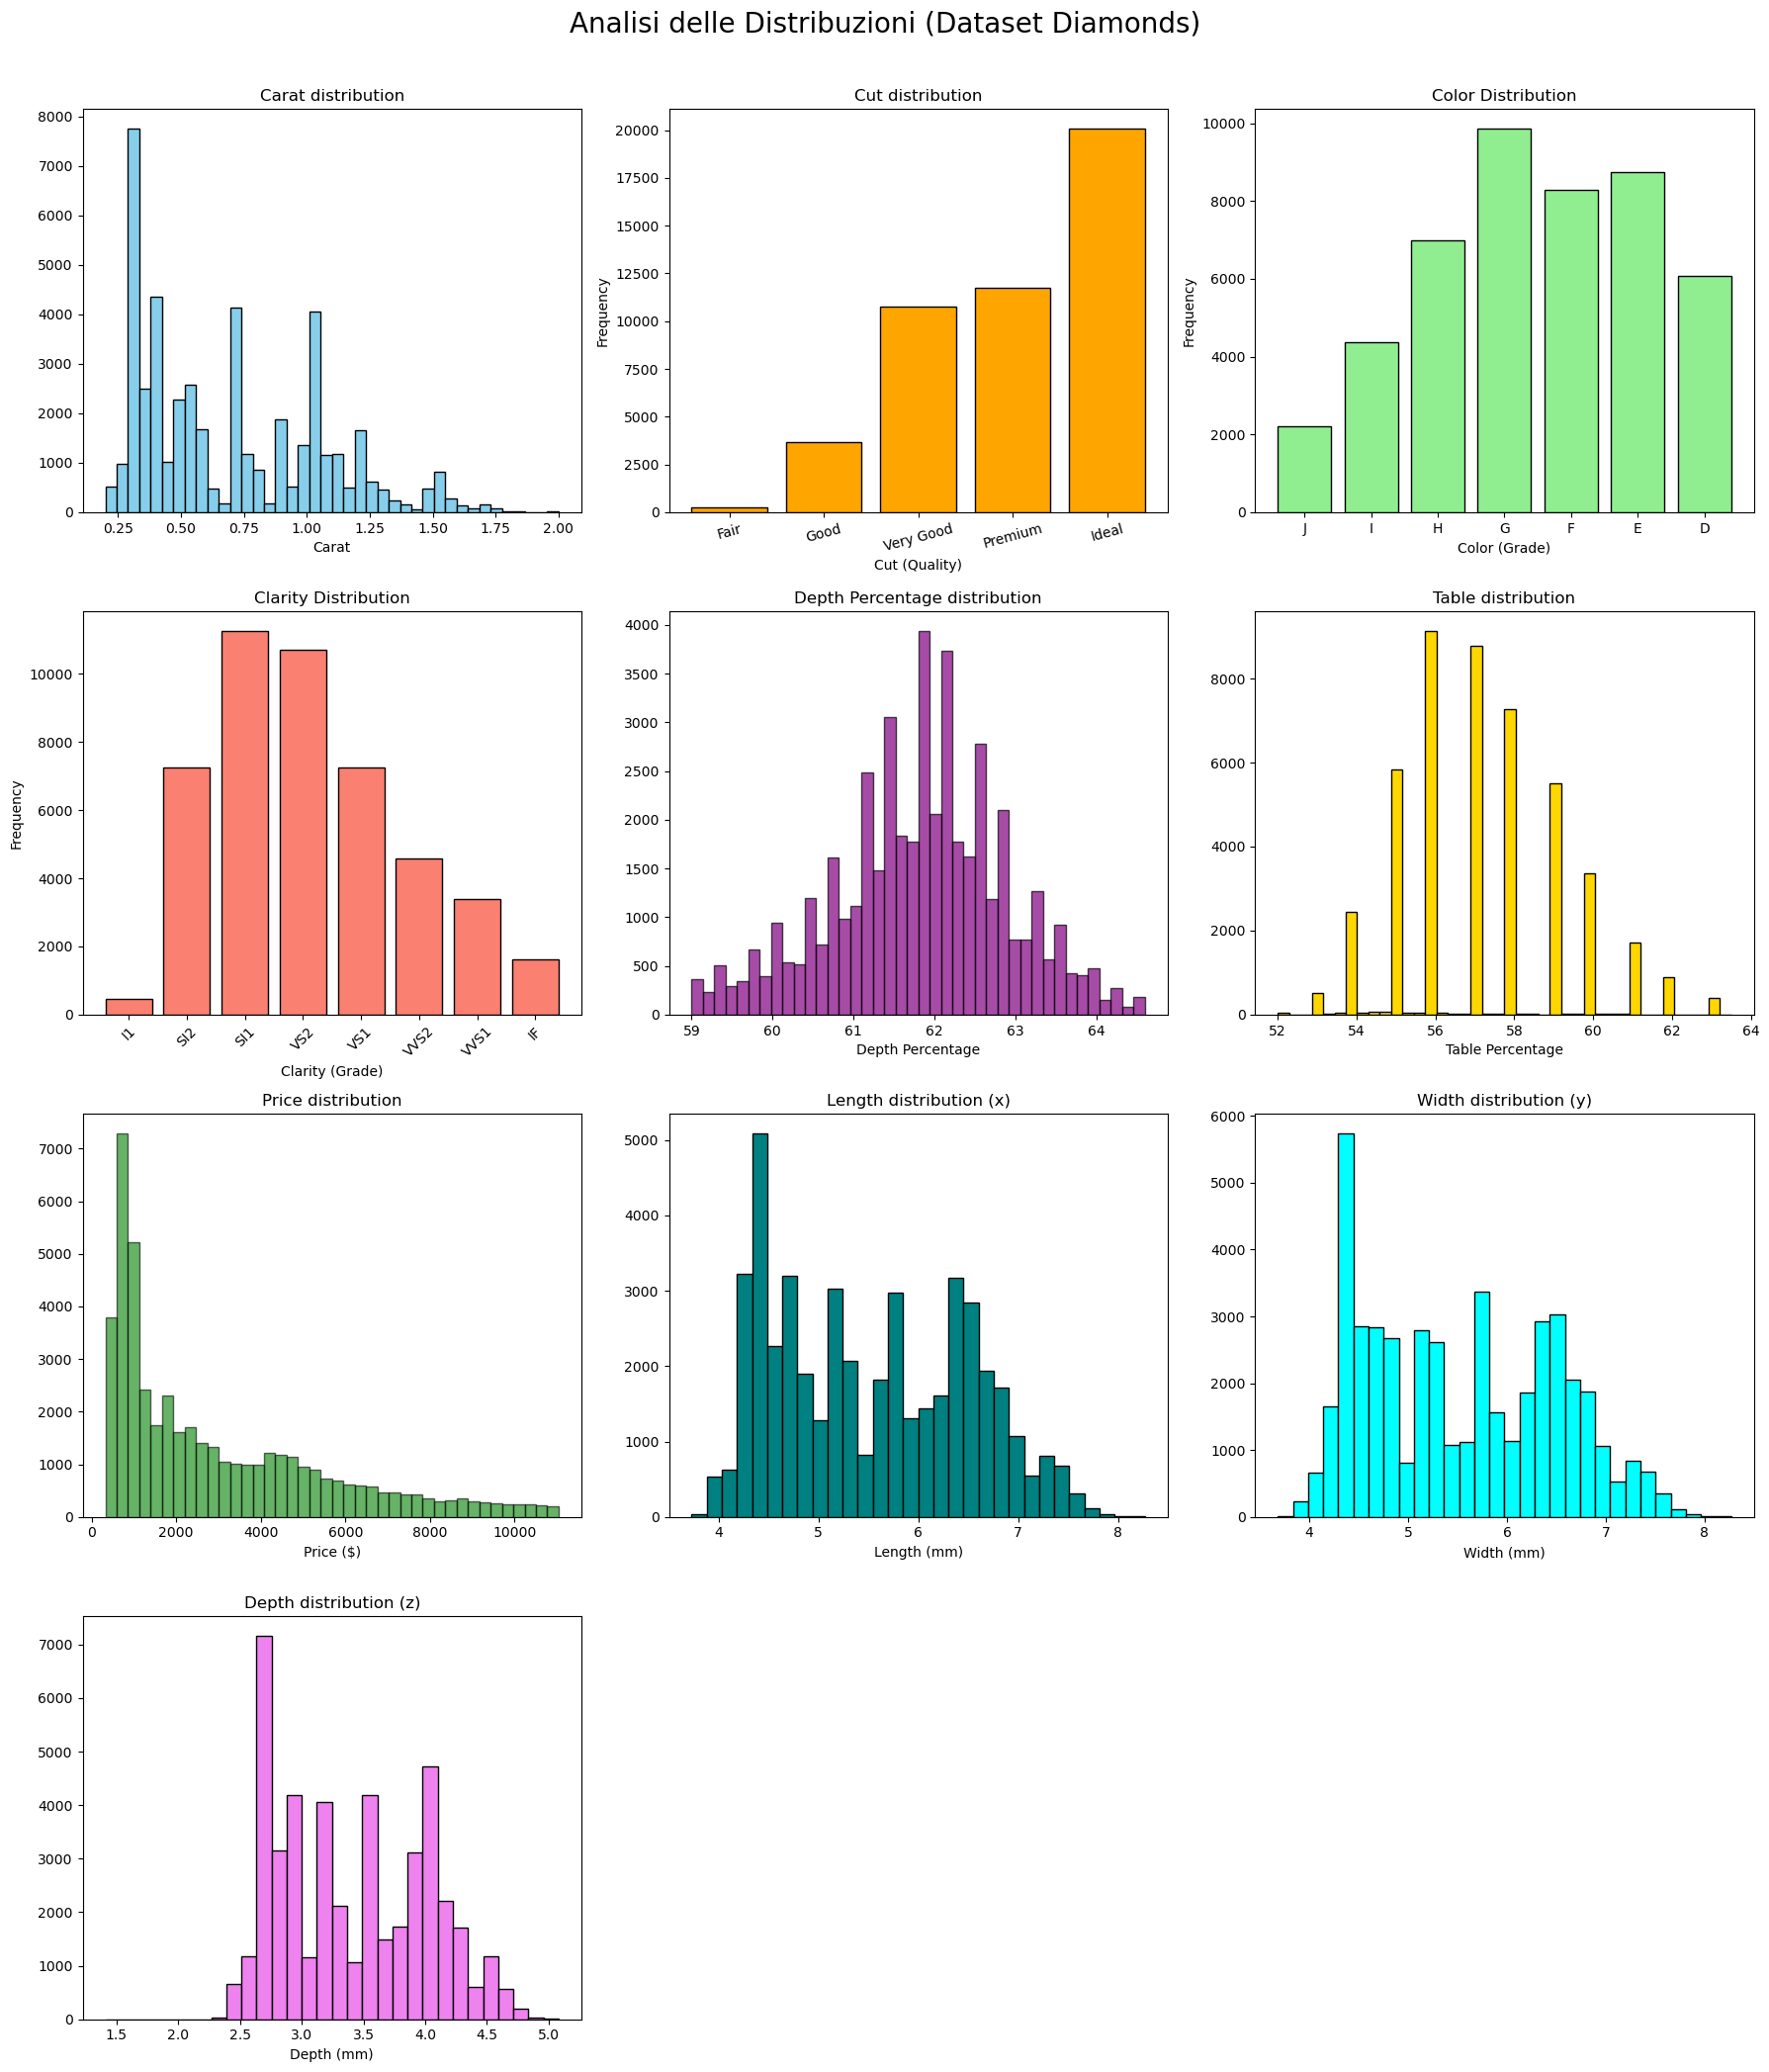

In [3]:
# --- DEFINIZIONE ETICHETTE ORIGINALI ---
cut_labels = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_labels = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_labels = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

# --- SETUP GRAFICO ---
fig, axes = plt.subplots(4, 3, figsize=(18, 22)) # Aumentato leggermente l'altezza
fig.suptitle('Analisi delle Distribuzioni (Dataset Diamonds)', fontsize=20)
ax = axes.flatten()

# --- 1. Carat (Istogramma) ---
ax[0].hist(df['carat'], bins=40, color='skyblue', edgecolor='black')
ax[0].set_title('Carat distribution')
ax[0].set_xlabel('Carat')

# --- 2. Cut (Barplot con Nomi) ---
cut_counts = df['cut'].value_counts().sort_index()
ax[1].bar(cut_counts.index, cut_counts.values, color='orange', edgecolor='black')
ax[1].set_title('Cut distribution')
ax[1].set_xlabel('Cut (Quality)')
ax[1].set_ylabel('Frequency')
# Sostituzione numeri con nomi
ax[1].set_xticks(cut_counts.index) # Posiziona i tick sui numeri (1,2,3,4,5)
ax[1].set_xticklabels(cut_labels, rotation=15) # Sostituisce con le stringhe

# --- 3. Color (Barplot con Nomi) ---
color_counts = df['color'].value_counts().sort_index()
ax[2].bar(color_counts.index, color_counts.values, color='lightgreen', edgecolor='black')
ax[2].set_title('Color Distribution')
ax[2].set_xlabel('Color (Grade)')
ax[2].set_ylabel('Frequency')
# Sostituzione numeri con nomi
ax[2].set_xticks(color_counts.index)
ax[2].set_xticklabels(color_labels)

# --- 4. Clarity (Barplot con Nomi) ---
clarity_counts = df['clarity'].value_counts().sort_index()
ax[3].bar(clarity_counts.index, clarity_counts.values, color='salmon', edgecolor='black')
ax[3].set_title('Clarity Distribution')
ax[3].set_xlabel('Clarity (Grade)')
ax[3].set_ylabel('Frequency')
# Sostituzione numeri con nomi
ax[3].set_xticks(clarity_counts.index)
ax[3].set_xticklabels(clarity_labels, rotation=45) # Ruotiamo perché sono tanti

# --- 5. Depth Percentage ---
ax[4].hist(df['depth_p'], bins=40, color='purple', alpha=0.7, edgecolor='black')
ax[4].set_title('Depth Percentage distribution')
ax[4].set_xlabel('Depth Percentage')

# --- 6. Table Percentage ---
ax[5].hist(df['table_p'], bins=40, color='gold', edgecolor='black')
ax[5].set_title('Table distribution')
ax[5].set_xlabel('Table Percentage')

# --- 7. Price ---
ax[6].hist(df['price'], bins=40, color='green', alpha=0.6, edgecolor='black')
ax[6].set_title('Price distribution')
ax[6].set_xlabel('Price ($)')

# --- 8. Length (x) ---
ax[7].hist(df['x'], bins=30, color='teal', edgecolor='black')
ax[7].set_title('Length distribution (x)')
ax[7].set_xlabel('Length (mm)')

# --- 9. Width (y) ---
ax[8].hist(df['y'], bins=30, color='cyan', edgecolor='black')
ax[8].set_title('Width distribution (y)')
ax[8].set_xlabel('Width (mm)')

# --- 10. Depth mm (z) ---
ax[9].hist(df['z'], bins=30, color='violet', edgecolor='black')
ax[9].set_title('Depth distribution (z)')
ax[9].set_xlabel('Depth (mm)')

# --- Pulizia ---
ax[10].axis('off')
ax[11].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.97]) 
plt.show()

# Mean e Std dataset variable

In [4]:
#Estrema variabilità
print(df.describe().T)

#Necessario standardizzare per permettere a GD di lavorare meglio

           count         mean          std     min     25%      50%      75%  \
carat    46532.0     0.697966     0.362025    0.20    0.37     0.59     1.01   
cut      46532.0     4.025724     1.014818    1.00    3.00     4.00     5.00   
color    46532.0     4.464820     1.685251    1.00    3.00     4.00     6.00   
clarity  46532.0     4.126773     1.643282    1.00    3.00     4.00     5.00   
depth_p  46532.0    61.804302     1.077341   59.00   61.20    61.90    62.50   
table_p  46532.0    57.238621     2.013841   52.00   56.00    57.00    59.00   
price    46532.0  2999.000107  2598.654394  326.00  880.00  2002.50  4523.00   
x        46532.0     5.521339     0.964476    3.73    4.62     5.39     6.39   
y        46532.0     5.526371     0.958648    3.68    4.63     5.40     6.39   
z        46532.0     3.413855     0.597215    1.41    2.85     3.33     3.96   

              max  
carat        2.00  
cut          5.00  
color        7.00  
clarity      8.00  
depth_p     64.60  

# Standardization and preparing dataset

Per avere un modello più preciso si può applicare log a price e carat (right skewed)
e perchè linearizzarebbe la relazione tra di loro.
Non Lo facciamo per stressare i vari algoritmi di ottimizzazione

Perché? Una funzione obiettivo mal condizionata (quella originale) è un banco di prova più difficile per confrontare gli algoritmi. Vedrai differenze maggiori tra Newton (che se ne frega della curvatura) e Gradiente Discesa (che soffrirà). Se linearizzi tutto col logaritmo, rendi il problema "troppo facile" e tutti gli algoritmi convergeranno velocemente, rendendo il confronto meno interessante.

Questo renderà le curve di convergenza più diverse tra loro e avrai più cose di cui parlare nella sezione "Results & Analysis" (es. "Il GD ha faticato a causa della non linearità, mentre Newton...").

X shape: (46532, 10)
y shape: (46532, 1)
Number of samples n =  46532
Dimension of each sample d =  10


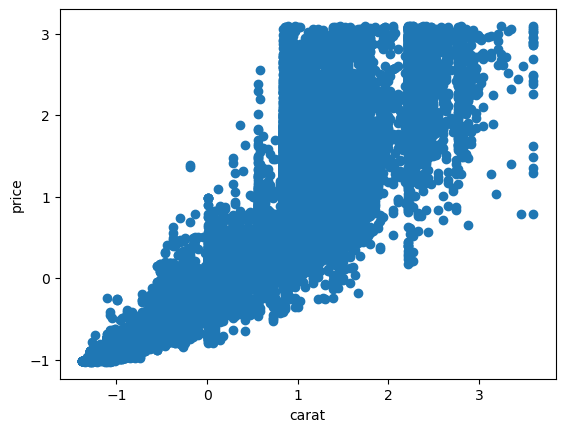

In [5]:
from sklearn.preprocessing import StandardScaler

#Funzione di standardizzazione manuale per vettori 1-D
def standardize(x):
  """Standardize vector 1-D"""
  mean_val = np.mean(x)
  std_val = np.std(x)
  x_scaled = (x - mean_val) / std_val
  return x_scaled

#Funzione per costruire le matrici
def build_model_data(regr, obj):
  """Creating data in Matrix Form"""
  num_samples = len(obj)
    
  # Aggiunge colonna di 1 (Bias)
  X = np.c_[np.ones(num_samples), regr]
    
  # Trasforma y da (n,) a (n, 1)
  y = obj.reshape(-1, 1)
    
  return X, y


# Estrazione dati
features = df.drop('price', axis=1).values
price = df['price'].values

# Standardizzazione delle features (X) con Sklearn
scaler = StandardScaler()
feat_scal = scaler.fit_transform(features)

# Standardizzo price
price_scal = standardize(price)

# Costruzione finale
X, y = build_model_data(feat_scal, price_scal)

# Verifica Dimensioni
print(f"X shape: {X.shape}")  # Deve essere (N, 10)
print(f"y shape: {y.shape}")  # Deve essere (N, 1) <-- Molto importante l'1 finale

# Take a look at our data - carat/price relation
#Oss: è non lineare
plt.xlabel ('carat')
plt.ylabel ('price')
plt.scatter(X[:,1], y)

print('Number of samples n = ', y.shape[0])
print('Dimension of each sample d = ', X.shape[1])


# Standardized Data Visualization

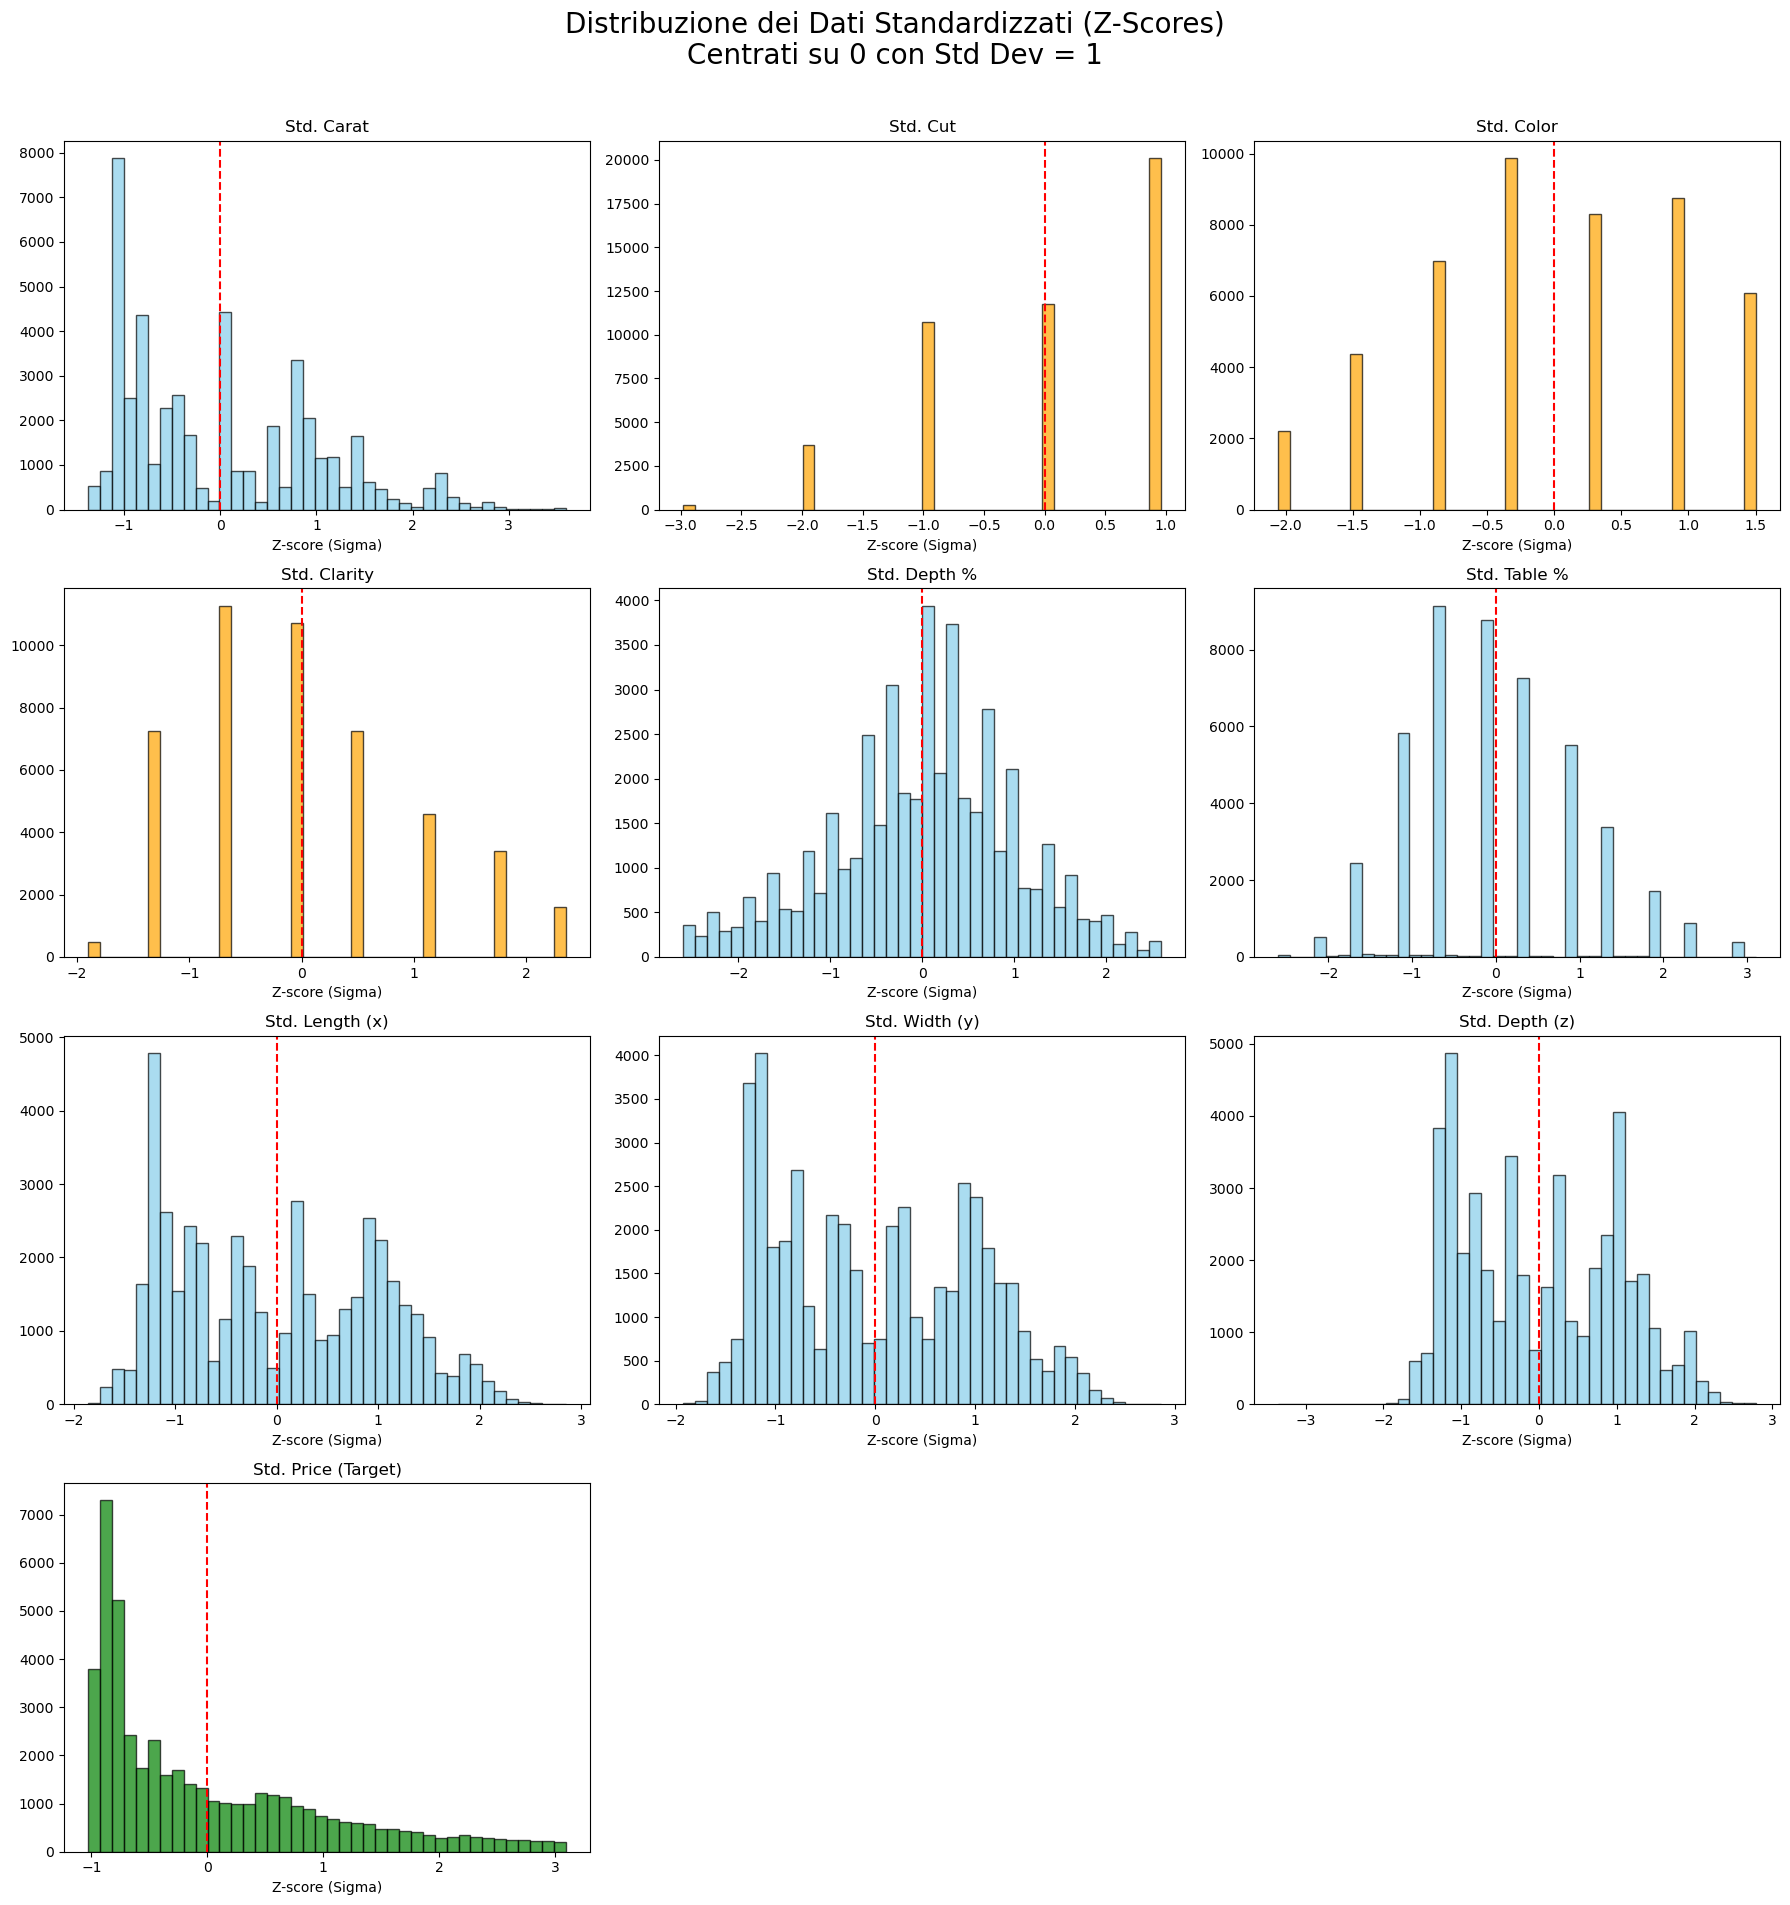

In [6]:

# 1. Definiamo i nomi delle feature nell'ordine esatto in cui sono in X
# Ricorda: X ha la colonna 0 che è il Bias (tutti 1), quindi la saltiamo.
feature_names = ['Carat', 'Cut', 'Color', 'Clarity', 'Depth %', 'Table %', 'Length (x)', 'Width (y)', 'Depth (z)']

# 2. Setup della Griglia (4 righe x 3 colonne)
fig, axes = plt.subplots(4, 3, figsize=(18, 20))
fig.suptitle('Distribuzione dei Dati Standardizzati (Z-Scores)\nCentrati su 0 con Std Dev = 1', fontsize=20)

# Appiattiamo gli assi per iterare facilmente
ax = axes.flatten()

# --- CICLO PER LE FEATURE (X) ---
# Iteriamo su i nomi delle feature.
# Nota: In X, la feature 'Carat' è alla colonna 1, non 0 (la 0 è il Bias).
for i, name in enumerate(feature_names):
    # Estraiamo i dati dalla colonna i+1
    data = X[:, i+1]
    
    # Creiamo l'istogramma
    # Usa un colore diverso per le variabili che erano categoriche (Cut, Color, Clarity -> indici 1, 2, 3)
    color = 'orange' if i in [1, 2, 3] else 'skyblue'
    
    ax[i].hist(data, bins=40, color=color, edgecolor='black', alpha=0.7)
    ax[i].set_title(f'Std. {name}')
    ax[i].set_xlabel('Z-score (Sigma)')
    
    # Aggiungiamo la linea della Media (deve essere 0)
    ax[i].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Mean (0)')

# --- GRAFICO DEL TARGET (y - Price) ---
# Lo mettiamo nella posizione 9 (decimo grafico)
ax[9].hist(y, bins=40, color='green', edgecolor='black', alpha=0.7)
ax[9].set_title('Std. Price (Target)')
ax[9].set_xlabel('Z-score (Sigma)')
ax[9].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Mean (0)')

# --- PULIZIA ---
# Nascondiamo gli slot vuoti (10 e 11)
ax[10].axis('off')
ax[11].axis('off')

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

# Confonto atteso tra algoritmi (ipotesi)

Questa è una scelta didattica eccellente. Mantenere i dati "grezzi" (senza logaritmo) rende il problema di ottimizzazione molto più "piccante".

Poiché la relazione tra Carati e Prezzo è esponenziale ma noi stiamo forzando un modello lineare, e poiché le scale delle variabili sono diverse (anche dopo la standardizzazione, le correlazioni creano distorsioni), la superficie della tua Loss Function non sarà una scodella rotonda perfetta, ma una **valle stretta e allungata**.

Ecco come si comporteranno i diversi "atleti" (algoritmi) su questo terreno difficile.

---

### 1. Gradient Descent (GD): "L'escursionista miope"
Il GD guarda solo la pendenza locale ($\nabla f$).
* **Il Problema:** In una valle stretta e lunga (problema *mal condizionato*), la pendenza più ripida non punta verso il fondo valle, ma verso la parete opposta!
* **Il Comportamento:** Farà un continuo **zig-zag**. Salterà da una parete all'altra della valle avanzando molto lentamente verso il minimo.
* **Previsione:** Vedrai una curva di convergenza che scende, poi rallenta drasticamente e ci mette migliaia di iterazioni per arrivare alla precisione alta.
* **Dipendenza da $L$:** Se il Learning Rate non è esattamente $1/L$, rischia di oscillare o esplodere.

### 2. Newton's Method: "Il cecchino"
Newton usa la Derivata Seconda (l'Hessiana $\nabla^2 f$), ovvero la curvatura.
* **Il Segreto:** "Vede" la forma della valle. Capisce che è stretta in una direzione e lunga nell'altra. Usa l'inversa dell'Hessiana per "rescalare" lo spazio.
* **Il Risultato Shock:** Poiché la Ridge Regression è un problema **Quadratico** (la funzione di costo è una parabola multidimensionale), il Metodo di Newton teoricamente **converge in 1 sola iterazione**.
    * Matematicamente: $w_{new} = w_{old} - (\nabla^2 f)^{-1} \nabla f$. Se $f$ è quadratica, questa formula porta direttamente al minimo esatto $w^*$.
* **Previsione:** Nel grafico Loss vs Iterazioni, vedrai Newton andare a zero (o a precisione macchina $10^{-15}$) istantaneamente, mentre GD è ancora all'inizio.
* **Il Costo:** Ogni passo costa molto ($O(d^3)$ per invertire la matrice), ma dato che $d \approx 10$, è irrisorio.

### 3. Stochastic Gradient Descent (SGD): "L'ubriaco veloce"
Invece di calcolare il gradiente su tutti i 45.000 diamanti, ne prende **uno a caso** per volta.
* **Il Problema:** Alcuni diamanti sono "anomali" o molto costosi. Il gradiente calcolato su di loro sarà sballato.
* **Il Comportamento:** La loss **oscillerà violentemente**. Non scenderà in modo monotono come GD. Sembrerà un grafico sismografico.
* **Previsione:** All'inizio scenderà velocissimo (in termini di tempo, non iterazioni), ma poi non si stabilizzerà mai sul minimo esatto, continuerà a ballarci intorno ("Noise floor"). Dovrai usare un learning rate decrescente ($\alpha_k = C/k$) per farlo convergere.

### 4. Nesterov Accelerated Gradient (AGD): "La palla pesante"
È il GD con l'aggiunta del concetto di **Momentum** (inerzia).
* **Il Meccanismo:** Immagina una palla pesante che rotola giù per la valle. Se il gradiente le dice di andare a zig-zag, l'inerzia accumulata la spinge ad andare dritto, cancellando le oscillazioni laterali.
* **Previsione:** Sarà molto più veloce del GD standard. Vedrai che "taglia le curve" e raggiunge il minimo con meno iterazioni, anche se soffrirà un po' di "overshoot" (supererà il minimo e tornerà indietro) prima di fermarsi.

---

### 📊 Tabella Riassuntiva delle Ipotesi

| Algoritmo | Velocità (Iterazioni) | Velocità (Tempo Reale) | Stabilità | Note per il Progetto |
| :--- | :--- | :--- | :--- | :--- |
| **Newton** | 🥇 **Imbattibile** (1 iter.) | 🥇 Veloce (per $d$ basso) | ⭐⭐⭐⭐⭐ | Sarà il tuo benchmark di perfezione. |
| **GD (Standard)** | 🐌 Lento | 🥈 Medio | ⭐⭐ | Soffrirà il "Mal Condizionamento". |
| **Nesterov** | 🥈 Buono | 🥈 Medio | ⭐⭐⭐ | Batterà GD nettamente. |
| **SGD** | 🥉 Molte iterazioni | 🥇 Velocissimo all'inizio | ⭐ | Rumorosissimo, non arriverà mai a $10^{-10}$ di errore. |

---

# Choosing Best Lambda with Cross-Validation


### 1\. Le due formule a confronto

#### La formula di Scikit-Learn (`Ridge` / `RidgeCV`)

Scikit-Learn, per default, lavora sulla **somma totale** degli errori. Non divide per il numero di righe ($n$). La sua formula è:

$$J_{sklearn} = \underbrace{\sum_{i=1}^n (y_i - \hat{y}_i)^2}_{\text{Errore Totale}} + \alpha \underbrace{\sum_{j=1}^d w_j^2}_{\text{Penalità}}$$

  * Qui il termine "Errore Totale" è enorme (perché sommi 45.000 errori).
  * Per bilanciare questo numero enorme, anche $\alpha$ (il nostro 11.51) deve essere un numero "grande".

#### La tua formula manuale (Ottimizzazione)

Noi, per stabilità numerica del gradiente, abbiamo deciso di lavorare sull'**errore medio**. Abbiamo diviso tutto per $n$:

$$J_{manual} = \underbrace{\frac{1}{2n} \sum_{i=1}^n (y_i - \hat{y}_i)^2}_{\text{Errore Medio}} + \frac{\lambda}{2} \underbrace{\sum_{j=1}^d w_j^2}_{\text{Penalità}}$$

  * Qui il termine "Errore Medio" è piccolo (è indipendente dal numero di righe).
  * Se usassimo lo stesso $\alpha = 11.51$ qui, la penalità sarebbe **45.000 volte più potente** dell'errore\! Schiaccerebbe tutti i pesi a zero perché "vincerebbe" facile contro l'errore medio.

-----

### 2\. La Conversione (Mantenere l'Equilibrio)

Perché il modello matematico sia lo stesso (cioè trovi lo stesso minimo $w^*$), il **rapporto di forza** tra la parte dati e la parte regolarizzazione deve essere identico.

Guarda i coefficienti delle due formule:

| Componente | Scikit-Learn | Manuale |
| :--- | :--- | :--- |
| **Peso sui Dati** | $1$ | $\frac{1}{2n}$ |
| **Peso sulla Regolarizzazione** | $\alpha$ | $\frac{\lambda}{2}$ |

Per avere lo stesso modello, il rapporto deve essere uguale:

$$\frac{\text{Peso Reg}}{\text{Peso Dati}} \quad \Rightarrow \quad \frac{\alpha}{1} = \frac{\lambda/2}{1/2n}$$

Semplifichiamo la parte destra ($\frac{\lambda}{2} \cdot 2n = \lambda \cdot n$):

$$\alpha = \lambda \cdot n$$

Da cui otteniamo la formula di conversione per trovare il tuo $\lambda$:

$$\lambda = \frac{\alpha}{n}$$

-----

### 3\. Calcolo Pratico per il tuo Progetto

  * **Alpha (da Sklearn):** $11.51395$
  * **n (Righe del dataset):** $46.532$ (circa)

$$\lambda = \frac{11.51395}{46532} \approx 0.000247$$

**Cosa significa questo numero?**
Significa che per ogni singolo diamante, la penalità che applichiamo è molto piccola ($0.00025$). Ma siccome ci sono 46.000 diamanti, la somma totale di queste penalità equivale all'11.51 di Scikit-Learn.


### 4\. Il Meccanismo Standard: Cross-Validation "Brute Force" (GridSearchCV)

  Questo è il metodo più intuitivo ma più lento. Se usi GridSearchCV, il processo è:
  * Definizione: Tu fornisci una lista di alphas (es. [0.1, 1, 10]).
  * Ciclo: Per ogni alpha:Divide il dataset in $K$ parti (folds).
  * Addestra su $K-1$ parti e valida sull'ultima. Calcola l'errore medio.
  * Selezione: Sceglie l'alpha con l'errore medio più basso.


In [7]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge

print(f"Dimensioni Dataset: {X.shape}")

#Provo 100 candidati distribuiti equamente tra 0.01 e 10000
alphas_to_test = np.logspace(-3, 3, 100)
param_grid = {'alpha': alphas_to_test}

# fit_intercept=False è CRUCIALE perché X ha già la colonna di 1.
model = Ridge(fit_intercept=False)

# cv=5: Divide i dati in 5 parti (80% train, 20% validation rotanti)
# scoring='neg_mean_squared_error': Sklearn cerca di massimizzare lo score, 
# quindi usa l'errore negativo. (Più vicino a 0 è meglio).
# n_jobs=-1: Usa tutti i core del processore in parallelo per velocizzare.
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X, y)

best_alpha_grid = grid_search.best_params_['alpha']

print(f"Miglior Alpha (Scala Somma Errori): {best_alpha_grid:.5f}")

#Lambda per il miglior risultato
lambda_opt = best_alpha_grid / X.shape[0]
print(f"Lambda per la mia funzione di ottimizzazione: {lambda_opt:.5f}")

#Di conseguenza scegliamo questo Lambda Set per confrontare i vari algoritmi e convergenza
lambda_set = [1e-5, 1e-4, 1e-3, 0.01, 0.1, 1.0]


Dimensioni Dataset: (46532, 10)
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Miglior Alpha (Scala Somma Errori): 4.97702
Lambda per la mia funzione di ottimizzazione: 0.00011


Se usassi il range da $10^{-3}$ a $10^3$ ($0.001$ - $1000$), il tuo progetto diventerebbe **molto meno interessante** dal punto di vista dell'ottimizzazione.

Ti **sconsiglio** questo range specifico, e ti spiego il perché analizzando i due estremi.

### 1\. Il Problema dell'Estremo Alto ($\lambda = 1000$)

Nel tuo progetto stai usando la formulazione dell'errore medio ($\frac{1}{2n}$).
In questa scala, i valori tipici degli autovalori della matrice dei dati ($X^T X / n$) sono piccoli (diciamo tra 0 e 10).

Se imposti $\lambda = 1000$:

  * La tua Hessiana diventa: $H \approx \text{Valori Piccoli} + 1000 \cdot I$.
  * Il termine $1000 \cdot I$ domina completamente. I dati non contano più nulla.
  * **Geometria:** La funzione diventa una **sfera perfetta** ($\kappa \approx 1.0001$).
  * **Conseguenza:** Gradient Descent, Nesterov e Newton convergeranno **tutti in 1 o 2 iterazioni**. Le linee sui grafici saranno sovrapposte e verticali. Non ci sarà nulla da commentare.
  * **Fisica:** Stai dicendo che l'unica cosa che conta è avere pesi zero ($w=0$). Il modello non imparerà nulla (Underfitting estremo).

### 2\. Il Problema dell'Estremo Basso ($\lambda = 10^{-3}$)

Il valore ottimale per la predizione che avevamo trovato era circa $10^{-4}$ ($0.00009$).
Se parti da $10^{-3}$:

  * Salti tutta la parte "difficile" e "caotica".
  * A $10^{-3}$, il problema è già abbastanza stabile. Il Gradiente Discesa funzionerà bene.
  * **Cosa ti perdi:** Ti perdi i grafici spettacolari dove GD oscilla e fallisce mentre Newton vince. È come fare un test di resistenza su un'auto guidando solo in un parcheggio piano invece che in montagna.

-----

### ✅ Il Compromesso Migliore

Per ottenere grafici belli, ti consiglio di spostare la "finestra" verso sinistra (verso valori più piccoli).

Usa questo set di 5 valori:

1.  **$10^{-5}$ (0.00001):** La "Hard Mode". Qui GD impazzisce. Dimostri la potenza di Newton.
2.  **$10^{-4}$ (0.0001):** La zona della "Miglior Predizione".
3.  **$10^{-3}$ (0.001):** Inizia a stabilizzarsi.
4.  **$10^{-2}$ (0.01):** Facile.
5.  **$10^{0}$ (1.0):** Molto facile. Oltre questo valore non ha senso andare.



# Gradient Descent Implementation

In [25]:

def compute_gradient(X,w,Xwmy,lambda_i,n):
  """Compute the gradient function."""
  grad = (1/n) * X.T.dot(Xwmy) + lambda_i * w
  return grad


def compute_loss_value(Xwmy,w,lambda_i,n):
  "Calculate loss value for the objective function: 1/2n * ||Xw - y||^2 + lambda/2 * ||w||^2"
  value = 1 / (2*n) * (Xwmy**2).sum() + (lambda_i / 2) * (w**2).sum()
  return value


def gradient_descent(X,y,initial_w,lambda_i,gamma,max_iters):
  """Gradient descent implementation."""
  
  n = X.shape[0]

  #Define vectors to store weights and loss function values
  ws = [initial_w]
  loss_values = []

  w = initial_w
  for n_iter in range(max_iters):

    Xwmy = X.dot(w) - y 

    #Computing loss value(to minimize) and gradient
    grad = compute_gradient(X,w,Xwmy,lambda_i,n)
    value = compute_loss_value(Xwmy,w,lambda_i,n)

    # update w by a gradient descent step
    w = w - gamma * grad

    #store w and loss function value
    ws.append(w)
    loss_values.append(value)

    # PRINT RESULTS:
    if n_iter % 10 == 0 or n_iter == max_iters - 1:
      w_str = ", ".join(["{:.4f}".format(wi) for wi in w.flatten()])
      print("Gradient Descent({bi}/{ti}): Loss Value={l:.5f}, w=[{weights}]".format(
        bi=n_iter, 
        ti=max_iters - 1, 
        l=value, 
        weights=w_str
      ))
  
  return loss_values,ws
  


## Naive GD

In [56]:

# Setup
lambda_set = [1e-5, 1e-4, 1e-3, 0.01, 0.1, 1.0]
gamma = 0.001
max_iters = 1000
initial_w = np.zeros((X.shape[1], 1))

# Lista per accumulare le righe
results_list = []

for lam in lambda_set:
  lv_GD, ws_GD = gradient_descent(X, y, initial_w, lam, gamma, max_iters)
    
    # Extracting the last iteration (the best)
  best_loss = lv_GD[-1]
  best_w = ws_GD[-1].flatten()
    
  # [lambda, loss, w0, w1, ..., wd]
  row = np.r_[lam, best_loss, best_w]
    
  results_list.append(row)


results_matrix = np.array(results_list)



Gradient Descent(0/999): Loss Value=0.50000, w=[0.0000, 0.0009, -0.0001, -0.0001, -0.0002, 0.0000, 0.0001, 0.0009, 0.0009, 0.0009]
Gradient Descent(10/999): Loss Value=0.46755, w=[0.0000, 0.0100, -0.0008, -0.0015, -0.0017, 0.0001, 0.0015, 0.0097, 0.0098, 0.0097]
Gradient Descent(20/999): Loss Value=0.43771, w=[0.0000, 0.0187, -0.0014, -0.0029, -0.0031, 0.0003, 0.0028, 0.0182, 0.0182, 0.0182]
Gradient Descent(30/999): Loss Value=0.41027, w=[0.0000, 0.0270, -0.0020, -0.0041, -0.0044, 0.0004, 0.0040, 0.0264, 0.0264, 0.0263]
Gradient Descent(40/999): Loss Value=0.38503, w=[0.0000, 0.0350, -0.0025, -0.0052, -0.0055, 0.0005, 0.0051, 0.0342, 0.0342, 0.0340]
Gradient Descent(50/999): Loss Value=0.36182, w=[0.0000, 0.0427, -0.0030, -0.0062, -0.0065, 0.0005, 0.0062, 0.0416, 0.0417, 0.0415]
Gradient Descent(60/999): Loss Value=0.34046, w=[0.0000, 0.0501, -0.0035, -0.0072, -0.0073, 0.0006, 0.0072, 0.0488, 0.0489, 0.0486]
Gradient Descent(70/999): Loss Value=0.32080, w=[-0.0000, 0.0572, -0.0038, -0

In [57]:
# Visualization
col_names = ['Lambda', 'Loss'] + [f'w{i}' for i in range(initial_w.shape[0])]
df_results = pd.DataFrame(results_matrix, columns=col_names)

print("\n--- Final results per Lambda ---")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_results.round(5)) 


#Esportazione in CSV (separato da virgola)
#df_results.to_csv('risultati_ridge.csv', index=False, float_format='%.5f')
# Esportazione in Excel (richiede openpyxl installato: pip install openpyxl)
# df_results.to_excel('risultati_ridge.xlsx', index=False)
#print("File salvati nella cartella di lavoro.")


--- Final results per Lambda ---
    Lambda     Loss   w0       w1       w2       w3       w4       w5       w6       w7       w8       w9
0  0.00001  0.07032 -0.0  0.24778  0.01257  0.02447  0.07784 -0.00321  0.00736  0.22388  0.22508  0.22239
1  0.00010  0.07034 -0.0  0.24777  0.01257  0.02447  0.07783 -0.00321  0.00736  0.22388  0.22508  0.22239
2  0.00100  0.07045 -0.0  0.24771  0.01256  0.02445  0.07778 -0.00321  0.00736  0.22383  0.22503  0.22234
3  0.01000  0.07156 -0.0  0.24711  0.01246  0.02422  0.07729 -0.00319  0.00741  0.22334  0.22454  0.22186
4  0.10000  0.08237 -0.0  0.24131  0.01152  0.02208  0.07258 -0.00300  0.00788  0.21860  0.21974  0.21716
5  1.00000  0.16435 -0.0  0.19471  0.00470  0.00701  0.03859 -0.00158  0.01086  0.17980  0.18057  0.17873
